# AXIS 1: Text Representation Comparison

Comparing TF-IDF vs Sentence Embeddings

In [1]:
%pip install matplotlib seaborn scikit-learn pandas sentence-transformers gensim spicy


[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from scipy.sparse import save_npz
import pickle
from collections import Counter
from sklearn.metrics import silhouette_samples
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE


K_VALUES = [3, 5, 7, 10, 15]
SEEDS = [42, 123, 456, 789]

# 1) Load data

In [3]:

df = pd.read_csv('../complete_preprocessing_final.csv')
texts = df['trunc_processed_text'].tolist()
true_labels = df['type'].values

print(f"Loaded {len(texts)} tickets")
print(f"Ground truth: {len(np.unique(true_labels))} categories")
print(df['type'].value_counts())

Loaded 27919 tickets
Ground truth: 4 categories
type
Incident    11093
Request      8030
Problem      5832
Change       2964
Name: count, dtype: int64


# 2) Helper function for coherence

In [4]:

def get_coherence(texts, labels, n_topics):
    tokenized = [t.split() for t in texts]
    dictionary = Dictionary(tokenized)
    
    topics = []
    for c in range(n_topics):
        cluster_texts = [tokenized[i] for i in range(len(labels)) if labels[i] == c]
        if len(cluster_texts) > 0:
            word_freq = {}
            for text in cluster_texts:
                for word in text:
                    word_freq[word] = word_freq.get(word, 0) + 1
            top = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:10]
            topics.append([w for w, f in top])
    
    if len(topics) > 0:
        cm = CoherenceModel(topics=topics, texts=tokenized, dictionary=dictionary, coherence='c_v')
        return cm.get_coherence()
    return 0.0

# 3) TF-IDF

In [5]:
vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.85, ngram_range=(1,2), sublinear_tf=True)
X_tfidf = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

print(f"TF IDF shape: {X_tfidf.shape}")

# Save for AXIS 2
save_npz('tfidfvectors.npz', X_tfidf)
with open('tfidfvectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

TF IDF shape: (27919, 5000)


# 4) Sentence Embeddings

In [6]:
import os
if os.path.exists('embeddings.npy'):
    X_emb = np.load('embeddings.npy')
    print(f"Loaded embeddings: {X_emb.shape}")
else:
    model = SentenceTransformer('all-MiniLM-L6-v2')
    X_emb = model.encode(texts, show_progress_bar=True, batch_size=32)
    np.save('embeddings.npy', X_emb)
    print(f"Generated embeddings: {X_emb.shape}")

Loaded embeddings: (27919, 384)


# 5) K-Means Clustering tf idf and embeddings

In [30]:
kmeans_results = []

for rep_name, X, metric in [('TF-IDF', X_tfidf, 'cosine'), ('Embeddings', X_emb, 'euclidean')]:
    print(f"\n{rep_name}")

    
    for k in K_VALUES:
        print(f"\nk={k}:")
        
        for seed in SEEDS:
            km = KMeans(n_clusters=k, random_state=seed, n_init=10)
            labels = km.fit_predict(X)
            
            sil = silhouette_score(X, labels, metric=metric)
            ari = adjusted_rand_score(true_labels, labels)
            nmi = normalized_mutual_info_score(true_labels, labels)
            coh = get_coherence(texts, labels, k)
            
            kmeans_results.append({
                'representation': rep_name,
                'algorithm': 'K-means',
                'k': k,
                'seed': seed,
                'silhouette': sil,
                'ari': ari,
                'nmi': nmi,
                'coherence': coh
            })
            
            print(f"  seed {seed}: sil={sil:.3f}, ari={ari:.3f}, nmi={nmi:.3f}, coh={coh:.3f}")

kmeans_df = pd.DataFrame(kmeans_results)
kmeans_df.to_csv('../Outputs/axis1_kmeans.csv')


TF-IDF

k=3:
  seed 42: sil=0.034, ari=0.304, nmi=0.298, coh=0.659
  seed 123: sil=0.034, ari=0.305, nmi=0.299, coh=0.659
  seed 456: sil=0.034, ari=0.304, nmi=0.298, coh=0.659
  seed 789: sil=0.034, ari=0.305, nmi=0.299, coh=0.659

k=5:
  seed 42: sil=0.038, ari=0.255, nmi=0.258, coh=0.760
  seed 123: sil=0.038, ari=0.255, nmi=0.258, coh=0.760
  seed 456: sil=0.038, ari=0.255, nmi=0.258, coh=0.760
  seed 789: sil=0.038, ari=0.255, nmi=0.258, coh=0.760

k=7:
  seed 42: sil=0.033, ari=0.223, nmi=0.306, coh=0.744
  seed 123: sil=0.033, ari=0.222, nmi=0.305, coh=0.742
  seed 456: sil=0.036, ari=0.295, nmi=0.365, coh=0.740
  seed 789: sil=0.035, ari=0.221, nmi=0.308, coh=0.759

k=10:
  seed 42: sil=0.035, ari=0.183, nmi=0.319, coh=0.732
  seed 123: sil=0.034, ari=0.165, nmi=0.309, coh=0.739
  seed 456: sil=0.034, ari=0.163, nmi=0.306, coh=0.739
  seed 789: sil=0.035, ari=0.190, nmi=0.306, coh=0.721

k=15:
  seed 42: sil=0.030, ari=0.135, nmi=0.303, coh=0.734
  seed 123: sil=0.031, ari=0.1

# 6) HAC Clustering tf idf and enbeddings 

In [8]:
hac_results = []

for rep_name, X in [('TF-IDF', X_tfidf), ('Embeddings', X_emb)]:
    print(f"\n{rep_name}")
  
    
    # Reduce TF-IDF dimensions for HAC
    if rep_name == 'TF-IDF':
        svd = TruncatedSVD(n_components=50, random_state=42)
        X_reduced = svd.fit_transform(X)
    else:
        X_reduced = X
    
    for k in K_VALUES:
        hac = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = hac.fit_predict(X_reduced)
        
        sil = silhouette_score(X_reduced, labels)
        ari = adjusted_rand_score(true_labels, labels)
        nmi = normalized_mutual_info_score(true_labels, labels)
        coh = get_coherence(texts, labels, k)
        
        hac_results.append({
            'representation': rep_name,
            'algorithm': 'HAC',
            'k': k,
            'seed': None,
            'silhouette': sil,
            'ari': ari,
            'nmi': nmi,
            'coherence': coh
        })
        
        print(f"k={k}: sil={sil:.3f}, ari={ari:.3f}, nmi={nmi:.3f}, coh={coh:.3f}")

hac_df = pd.DataFrame(hac_results)
hac_df.to_csv('../Outputs/axis1_hac.csv')



TF-IDF
k=3: sil=0.086, ari=0.243, nmi=0.222, coh=0.663
k=5: sil=0.106, ari=0.272, nmi=0.292, coh=0.728
k=7: sil=0.109, ari=0.269, nmi=0.325, coh=0.749
k=10: sil=0.104, ari=0.185, nmi=0.305, coh=0.735
k=15: sil=0.099, ari=0.163, nmi=0.321, coh=0.726

Embeddings
k=3: sil=0.116, ari=0.259, nmi=0.254, coh=0.630
k=5: sil=0.097, ari=0.235, nmi=0.252, coh=0.751
k=7: sil=0.059, ari=0.213, nmi=0.301, coh=0.763
k=10: sil=0.062, ari=0.174, nmi=0.312, coh=0.755
k=15: sil=0.056, ari=0.122, nmi=0.286, coh=0.707


# 7) Results Overview

In [9]:
all_results = pd.concat([kmeans_df, hac_df], ignore_index=True)
all_results.to_csv('../Outputs/axis1_all_results.csv', index=False)

print("All results:")
print(all_results.head(20))
print(f"\nTotal rows: {len(all_results)}")

All results:
   representation algorithm   k seed  silhouette       ari       nmi  \
0          TF-IDF   K-means   3   42    0.033908  0.304347  0.298431   
1          TF-IDF   K-means   3  123    0.033909  0.304652  0.298691   
2          TF-IDF   K-means   3  456    0.033910  0.304442  0.298436   
3          TF-IDF   K-means   3  789    0.033908  0.304766  0.298773   
4          TF-IDF   K-means   5   42    0.038113  0.255345  0.258264   
5          TF-IDF   K-means   5  123    0.038108  0.255140  0.258342   
6          TF-IDF   K-means   5  456    0.038120  0.255298  0.258446   
7          TF-IDF   K-means   5  789    0.038121  0.255152  0.258426   
8          TF-IDF   K-means   7   42    0.032964  0.222551  0.305564   
9          TF-IDF   K-means   7  123    0.033069  0.222288  0.305318   
10         TF-IDF   K-means   7  456    0.036026  0.295428  0.365353   
11         TF-IDF   K-means   7  789    0.034605  0.221321  0.307786   
12         TF-IDF   K-means  10   42    0.034845  0

# 8) Visualizations

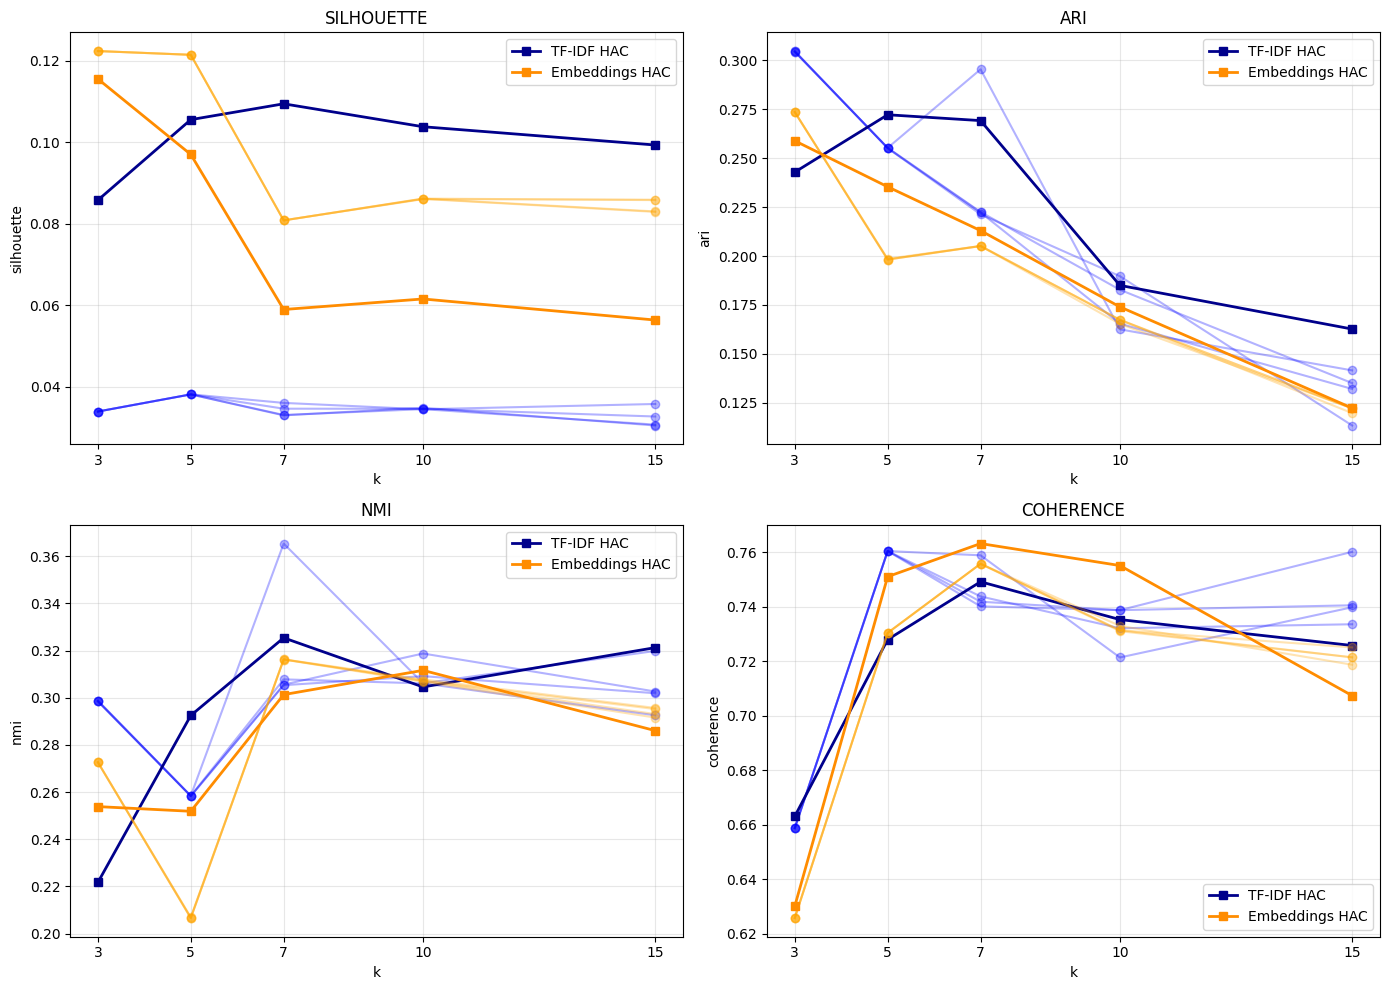

In [10]:
# Plot metrics across k values, dark color for HAC (Dark blue and dark orange), lighter for K-means (light blue and light orange)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
metrics = ['silhouette', 'ari', 'nmi', 'coherence']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    for rep in ['TF-IDF', 'Embeddings']:
        for algo in ['K-means', 'HAC']:
            data = all_results[(all_results['representation']==rep) & (all_results['algorithm']==algo)]
            
            if algo == 'K-means':
                for seed in SEEDS:
                    seed_data = data[data['seed']==seed]
                    ax.plot(seed_data['k'], seed_data[metric], 'o-', alpha=0.3, 
                           color='blue' if rep=='TF-IDF' else 'orange')
            else:
                ax.plot(data['k'], data[metric], 's-', linewidth=2,
                       label=f"{rep} HAC",
                       color='darkblue' if rep=='TF-IDF' else 'darkorange')
    
    ax.set_xlabel('k')
    ax.set_ylabel(metric)
    ax.set_title(metric.upper())
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xticks(K_VALUES)

plt.tight_layout()
plt.savefig('../Outputs/axis1_metrics.png')
plt.show()

# 9) Comparison at k=5

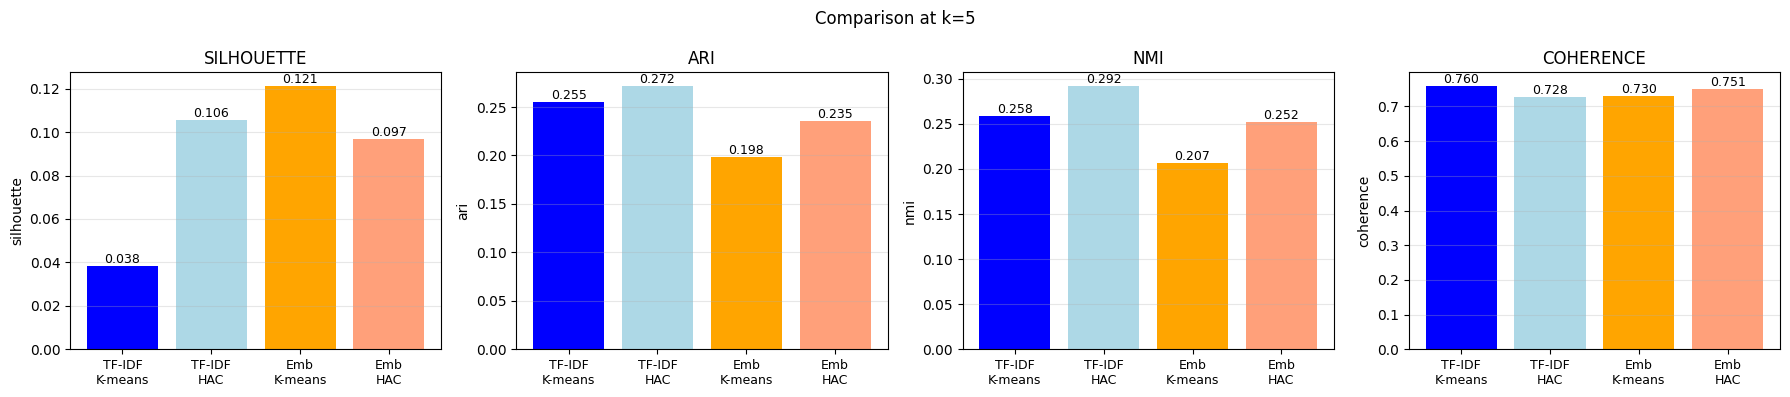

In [11]:

k5_data = all_results[all_results['k']==5].copy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for idx, metric in enumerate(['silhouette', 'ari', 'nmi', 'coherence']):
    ax = axes[idx]
    
    x_pos = np.arange(4)
    labels = ['TF-IDF\nK-means', 'TF-IDF\nHAC', 'Emb\nK-means', 'Emb\nHAC']
    
    # Average K-means across seeds, HAC has single value
    values = [
        k5_data[(k5_data['representation']=='TF-IDF') & (k5_data['algorithm']=='K-means')][metric].mean(),
        k5_data[(k5_data['representation']=='TF-IDF') & (k5_data['algorithm']=='HAC')][metric].values[0],
        k5_data[(k5_data['representation']=='Embeddings') & (k5_data['algorithm']=='K-means')][metric].mean(),
        k5_data[(k5_data['representation']=='Embeddings') & (k5_data['algorithm']=='HAC')][metric].values[0]
    ]
    
    bars = ax.bar(x_pos, values, color=['blue', 'lightblue', 'orange', 'lightsalmon'])
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(metric)
    ax.set_title(metric.upper())
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparison at k=5')
plt.tight_layout()
plt.savefig('../Outputs/axis1_k=5_comparison.png')
plt.show()

# 10) Best Configurations

In [12]:
print("Best by Silhouette:")
best_sil = all_results.loc[all_results['silhouette'].idxmax()]
print(f"  {best_sil['representation']} + {best_sil['algorithm']} at k={best_sil['k']}")
print(f"  Silhouette: {best_sil['silhouette']:.4f}")

print("\nBest by ARI:")
best_ari = all_results.loc[all_results['ari'].idxmax()]
print(f"  {best_ari['representation']} + {best_ari['algorithm']} at k={best_ari['k']}")
print(f"  ARI: {best_ari['ari']:.4f}")

print("\nBest by Coherence:")
best_coh = all_results.loc[all_results['coherence'].idxmax()]
print(f"  {best_coh['representation']} + {best_coh['algorithm']} at k={best_coh['k']}")
print(f"  Coherence: {best_coh['coherence']:.4f}")

Best by Silhouette:
  Embeddings + K-means at k=3
  Silhouette: 0.1224

Best by ARI:
  TF-IDF + K-means at k=3
  ARI: 0.3048

Best by Coherence:
  Embeddings + HAC at k=7
  Coherence: 0.7632


# 11) Detailed Analysis at k=5

In [13]:
# Get cluster labels for k=5, seed=42
km_tfidf = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_tfidf = km_tfidf.fit_predict(X_tfidf)

km_emb = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_emb = km_emb.fit_predict(X_emb)

print("Cluster sizes at k=5:")
print("\nTF-IDF:")
for i in range(5):
    count = (labels_tfidf == i).sum()
    pct = (count / len(labels_tfidf)) * 100
    print(f"  Cluster {i}: {count:6,} ({pct:5.3f}%)")

print("\nEmbeddings:")
for i in range(5):
    count = (labels_emb == i).sum()
    pct = (count / len(labels_emb)) * 100
    print(f"  Cluster {i}: {count:6,} ({pct:5.3f}%)")

Cluster sizes at k=5:

TF-IDF:
  Cluster 0:  5,514 (19.750%)
  Cluster 1: 12,292 (44.027%)
  Cluster 2:  3,754 (13.446%)
  Cluster 3:  3,763 (13.478%)
  Cluster 4:  2,596 (9.298%)

Embeddings:
  Cluster 0:  5,985 (21.437%)
  Cluster 1:  3,999 (14.324%)
  Cluster 2:  3,910 (14.005%)
  Cluster 3:  3,861 (13.829%)
  Cluster 4: 10,164 (36.405%)


# 12) Confusion Matrix Heatmap (k=5, seed=42)

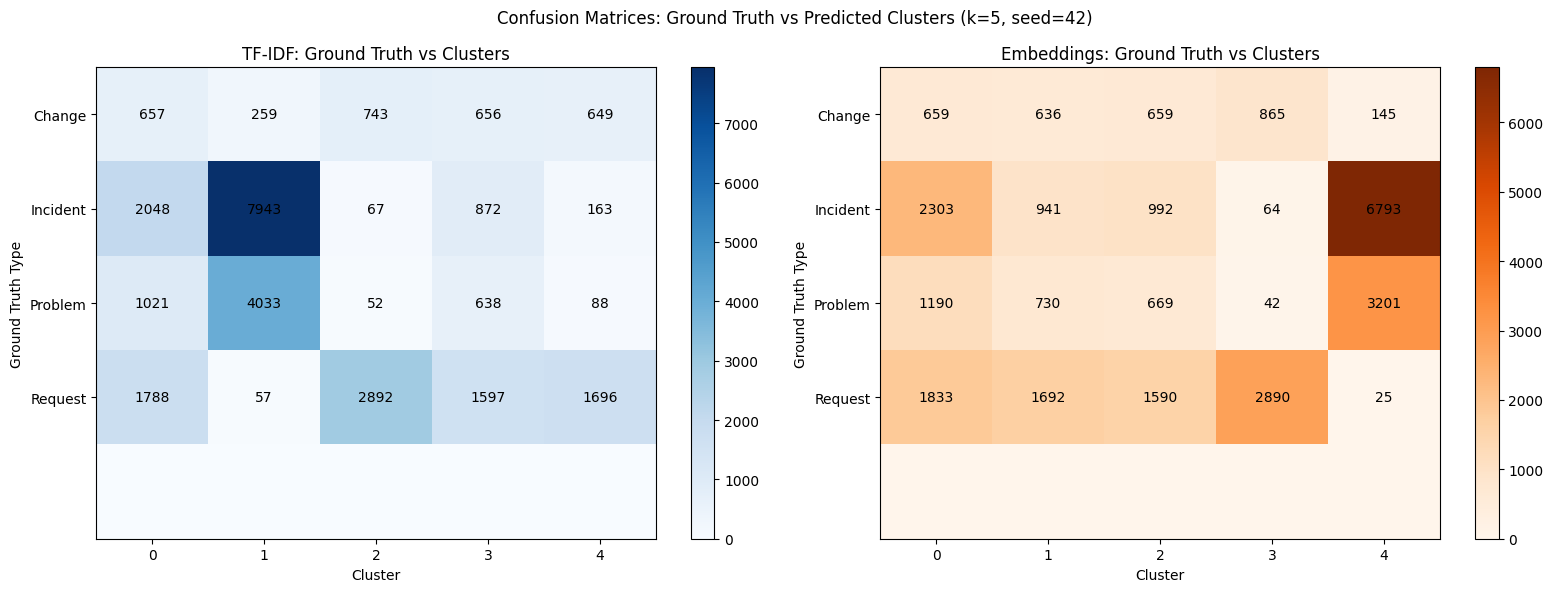


Ground truth categories: ['Change', 'Incident', 'Problem', 'Request']


In [14]:

km_tfidf_s42 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_tfidf_s42 = km_tfidf_s42.fit_predict(X_tfidf)

km_emb_s42 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_emb_s42 = km_emb_s42.fit_predict(X_emb)


le = LabelEncoder()
true_labels_numeric = le.fit_transform(true_labels)


cm_tfidf = confusion_matrix(true_labels_numeric, labels_tfidf_s42)
cm_emb = confusion_matrix(true_labels_numeric, labels_emb_s42)


label_names = le.classes_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# TF-IDF heatmap
im1 = axes[0].imshow(cm_tfidf, cmap='Blues', aspect='auto')
axes[0].set_title('TF-IDF: Ground Truth vs Clusters')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Ground Truth Type')
axes[0].set_xticks(range(5))
axes[0].set_yticks(range(len(label_names)))
axes[0].set_yticklabels(label_names)

for i in range(len(label_names)):
    for j in range(5):
        axes[0].text(j, i, f'{cm_tfidf[i, j]}',
                    ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im1, ax=axes[0])

# Embeddings heatmap
im2 = axes[1].imshow(cm_emb, cmap='Oranges', aspect='auto')
axes[1].set_title('Embeddings: Ground Truth vs Clusters')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Ground Truth Type')
axes[1].set_xticks(range(5))
axes[1].set_yticks(range(len(label_names)))
axes[1].set_yticklabels(label_names)

for i in range(len(label_names)):
    for j in range(5):
        axes[1].text(j, i, f'{cm_emb[i, j]}',
                    ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im2, ax=axes[1])

plt.suptitle('Confusion Matrices: Ground Truth vs Predicted Clusters (k=5, seed=42)', 
             )
plt.tight_layout()
plt.savefig('../Outputs/axis1_confusion_matrices.png')
plt.show()

print(f"\nGround truth categories: {list(label_names)}")

# 12) Metric Comparison Bar Chart (k=5, seed=42 only)

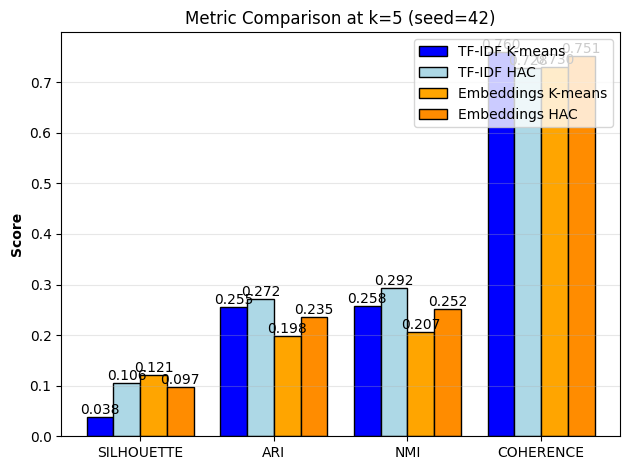

In [17]:
# Get k=5, seed=42 results
k5_s42 = all_results[(all_results['k']==5) & ((all_results['seed']==42) | (all_results['seed'].isna()))].copy()

fig, ax = plt.subplots()

metrics = ['silhouette', 'ari', 'nmi', 'coherence']
x_pos = np.arange(len(metrics))
width = 0.2

configs = [
    ('TF-IDF', 'K-means', 'blue'),
    ('TF-IDF', 'HAC', 'lightblue'),
    ('Embeddings', 'K-means', 'orange'),
    ('Embeddings', 'HAC', 'darkorange')
]
    
for i, (rep, algo, color) in enumerate(configs):
    subset = k5_s42[(k5_s42['representation']==rep) & (k5_s42['algorithm']==algo)]
    values = [subset[m].values[0] for m in metrics]
    
    bars = ax.bar(x_pos + i*width, values, width, 
                  label=f'{rep} {algo}', color=color, edgecolor='black')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}', ha='center', va='bottom')

ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Metric Comparison at k=5 (seed=42)')
ax.set_xticks(x_pos + width * 1.5)
ax.set_xticklabels([m.upper() for m in metrics])
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../Outputs/axis1_metrics_k5_s42.png')
plt.show()


# 13) Cluster Size Distribution (k=5, seed=42)

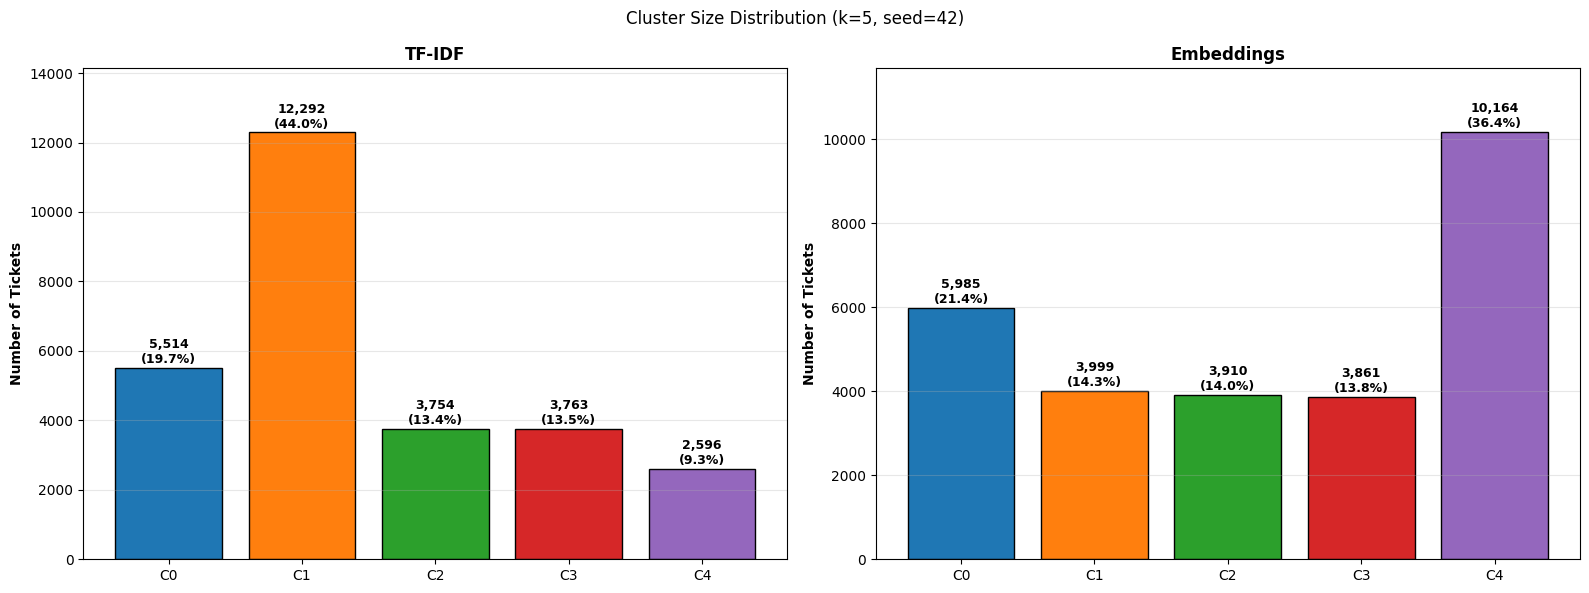

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (labels, rep_name, color) in zip(axes, [
    (labels_tfidf_s42, 'TF-IDF', 'blue'),
    (labels_emb_s42, 'Embeddings', 'orange')
]):
    sizes = pd.Series(labels).value_counts().sort_index()
    colors_list = [plt.cm.tab10.colors[i] for i in range(5)]
    
    bars = ax.bar([f'C{i}' for i in range(5)],
                  sizes.values,
                  color=colors_list,
                  edgecolor='black', linewidth=1)
    
    # Add value labels
    for bar, val in zip(bars, sizes.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 50,
                f'{val:,}\n({val/len(labels)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title(f'{rep_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Tickets', fontweight='bold')
    ax.set_ylim(0, max(sizes.values) * 1.15)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cluster Size Distribution (k=5, seed=42)')
plt.tight_layout()
plt.savefig('../Outputs/axis1_cluster_sizes.png')
plt.show()


# 14) t-SNE plots

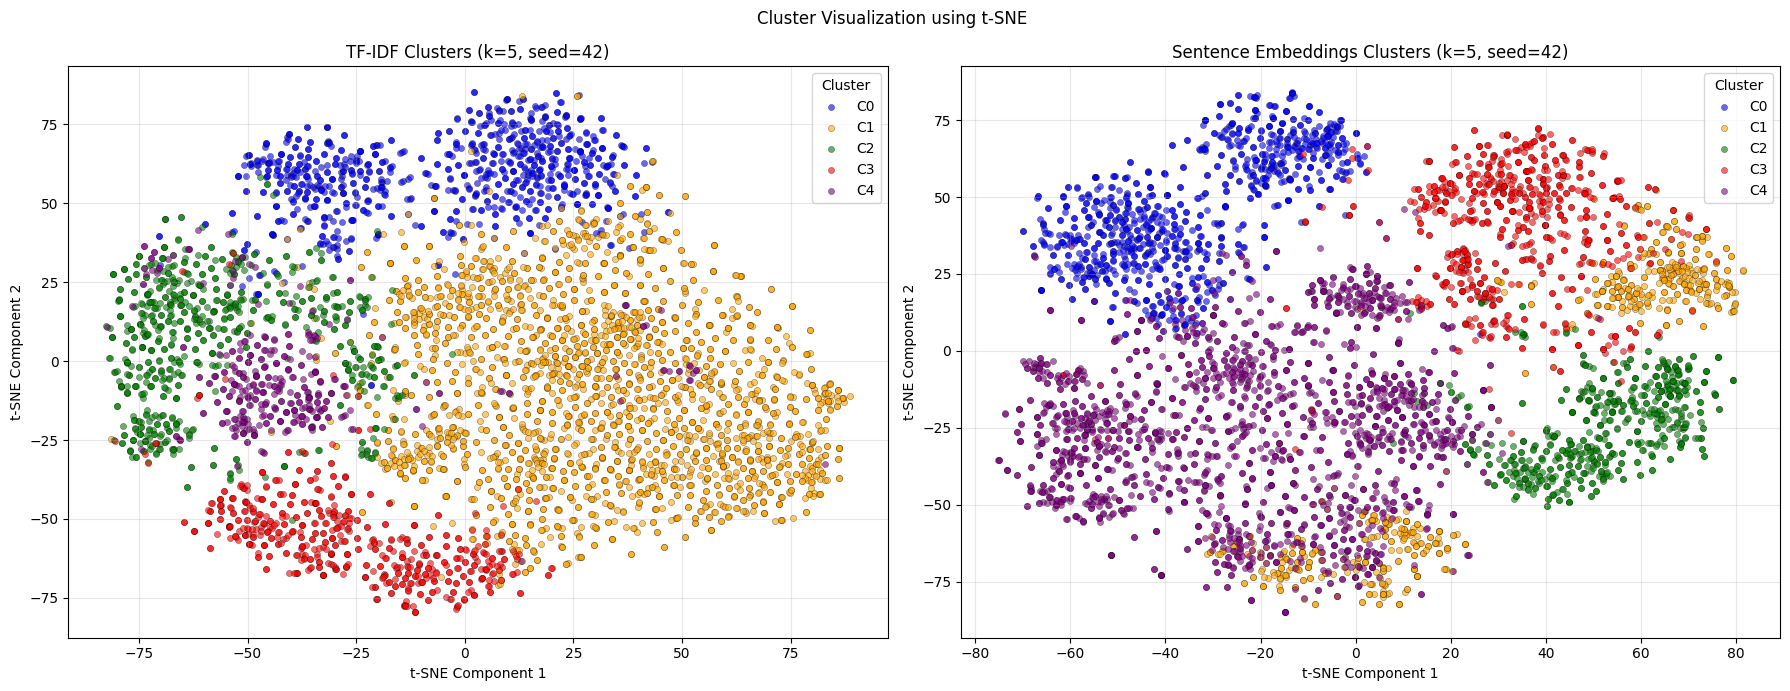

In [24]:
tsne_tfidf = TSNE(n_components=2, random_state=42, perplexity=30)
X_tfidf_2d = tsne_tfidf.fit_transform(X_tfidf.toarray()[:5000])  

tsne_emb = TSNE(n_components=2, random_state=42, perplexity=30)
X_emb_2d = tsne_emb.fit_transform(X_emb[:5000])  


labels_tfidf_sample = labels_tfidf_s42[:5000]
labels_emb_sample = labels_emb_s42[:5000]


fig, axes = plt.subplots(1, 2, figsize=(18, 7))


colors = [ 'blue', 'orange', 'green', 'red', 'purple']
cluster_names = ['C0', 'C1', 'C2', 'C3', 'C4']


for c in range(5):
    mask = labels_tfidf_sample == c
    axes[0].scatter(X_tfidf_2d[mask, 0], X_tfidf_2d[mask, 1], 
                   c=colors[c], label=cluster_names[c], 
                   alpha=0.6, s=20, edgecolors='black', linewidth=0.3)

axes[0].set_title('TF-IDF Clusters (k=5, seed=42)')
axes[0].set_xlabel('t-SNE Component 1')
axes[0].set_ylabel('t-SNE Component 2')
axes[0].legend(title='Cluster', loc='best')
axes[0].grid(alpha=0.3)

for c in range(5):
    mask = labels_emb_sample == c
    axes[1].scatter(X_emb_2d[mask, 0], X_emb_2d[mask, 1], 
                   c=colors[c], label=cluster_names[c], 
                   alpha=0.6, s=20, edgecolors='black', linewidth=0.3)

axes[1].set_title('Sentence Embeddings Clusters (k=5, seed=42)')
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
axes[1].legend(title='Cluster', loc='best')
axes[1].grid(alpha=0.3)

plt.suptitle('Cluster Visualization using t-SNE ')
plt.tight_layout()
plt.savefig('../Outputs/axis1_scatter_plots.png')
plt.show()



# 15) Top 10 Words per Cluster

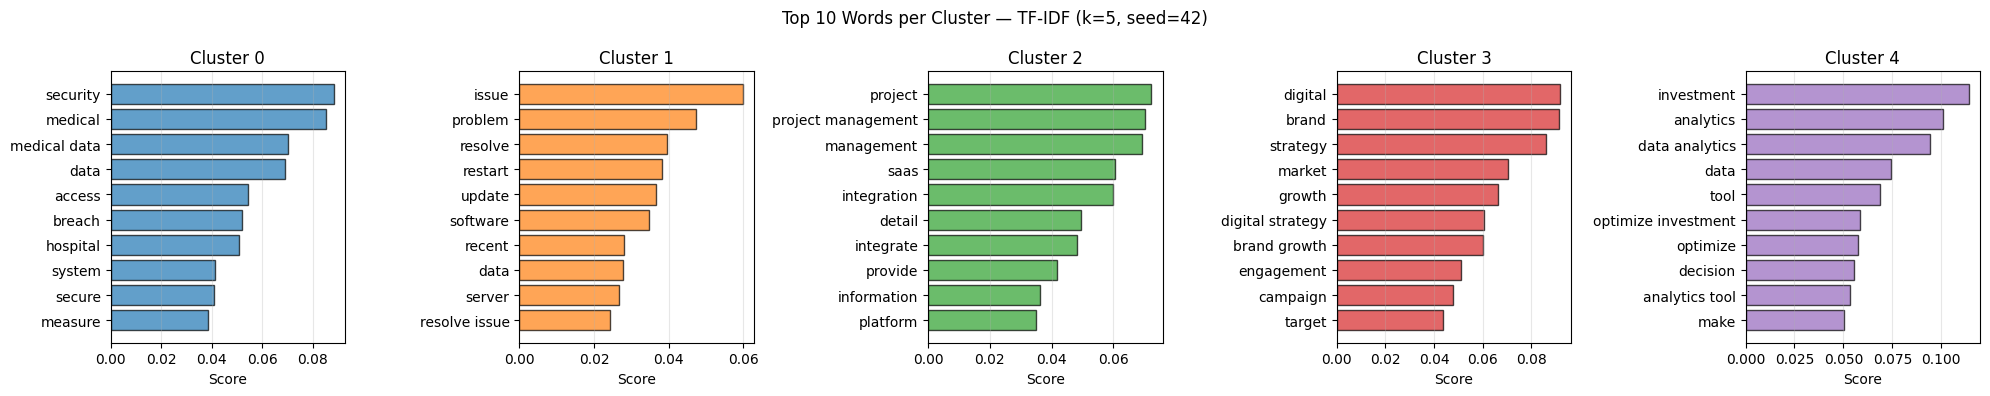

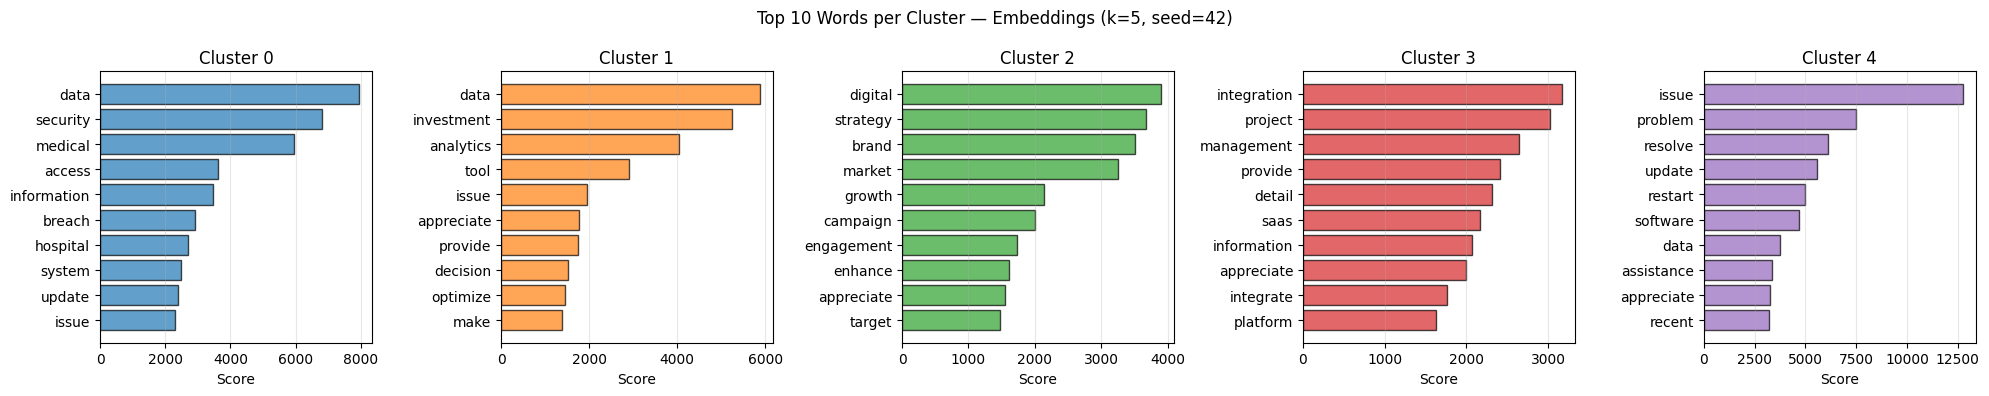

In [27]:


def plot_top_words(X, labels, feature_names, rep_name, filename):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    colors = plt.cm.tab10.colors
    
    for c in range(5):
        ax = axes[c]
        mask = labels == c
        
        if feature_names is not None:
            # TF-IDF: use centroid
            centroid = np.asarray(X[mask].mean(axis=0)).flatten()
            top_idx = centroid.argsort()[::-1][:10]
            top_words = [feature_names[i] for i in top_idx]
            top_scores = [centroid[i] for i in top_idx]
        else:
            # Embeddings: use word frequency
            cluster_indices = np.where(mask)[0]
            word_freq = Counter()
            for i in cluster_indices:
                word_freq.update(texts[i].split())
            top_items = word_freq.most_common(10)
            top_words = [w for w, f in top_items]
            top_scores = [f for w, f in top_items]
        
        # Plot horizontal bar chart
        ax.barh(range(10), top_scores[::-1], color=colors[c], alpha=0.7, edgecolor='black')
        ax.set_yticks(range(10))
        ax.set_yticklabels(top_words[::-1])
        ax.set_xlabel('Score')
        ax.set_title(f'Cluster {c}')
        ax.grid(axis='x', alpha=0.3)
    
    plt.suptitle(f'Top 10 Words per Cluster — {rep_name} (k=5, seed=42)')
    plt.tight_layout()
    plt.savefig(f'../Outputs/{filename}')
    plt.show()
   

# Plot for TF-IDF
plot_top_words(X_tfidf, labels_tfidf_s42, feature_names, 
               'TF-IDF' , 'axis1_top_words_tfidf.png')

# Plot for Embeddings
plot_top_words(X_emb, labels_emb_s42, None, 
               'Embeddings', 'axis1_top_words_emb.png')

# 16) Silhouette Plot (k=5, seed=42)

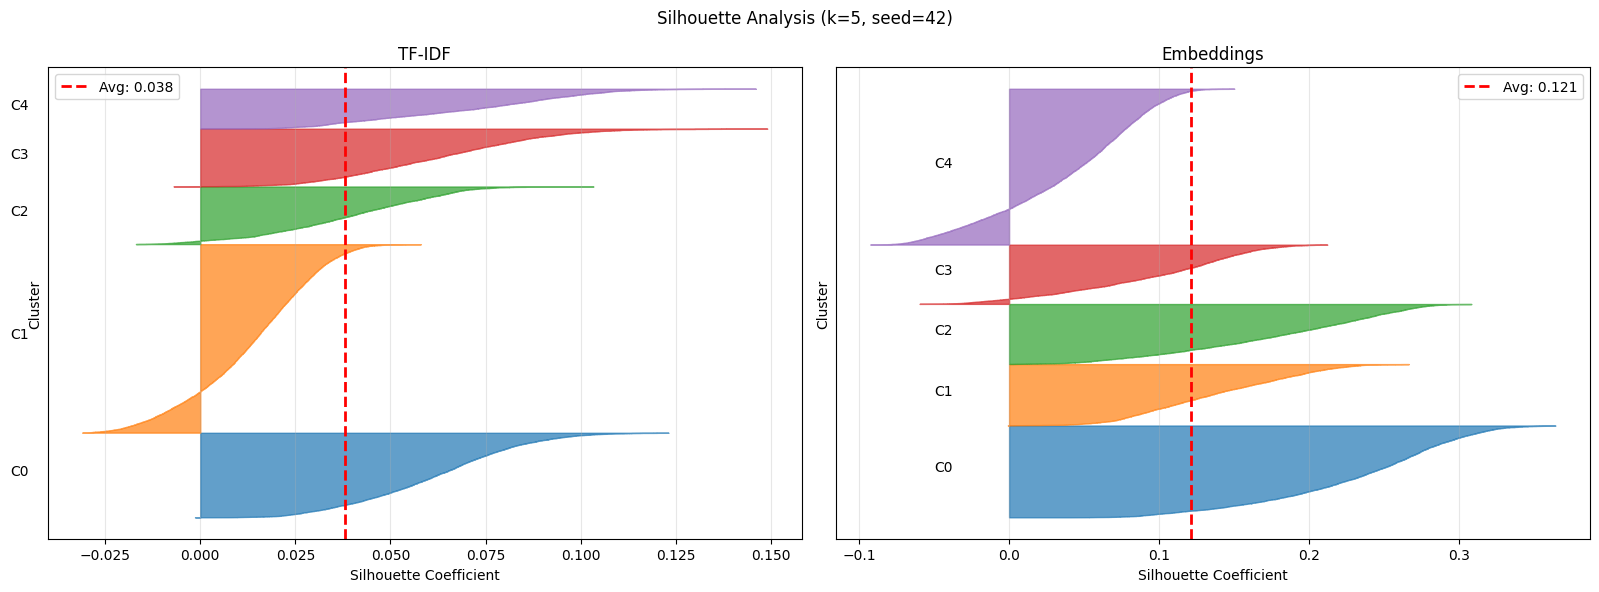

In [28]:


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (X, labels, rep_name, metric) in zip(axes, [
    (X_tfidf, labels_tfidf_s42, 'TF-IDF', 'cosine'),
    (X_emb, labels_emb_s42, 'Embeddings', 'euclidean')
]):
   
    silhouette_vals = silhouette_samples(X, labels, metric=metric)
    avg_score = silhouette_score(X, labels, metric=metric)
    
    y_lower = 10
    colors = plt.cm.tab10.colors
    
    for c in range(5):
        
        cluster_silhouette_vals = silhouette_vals[labels == c]
        cluster_silhouette_vals.sort()
        
        size_cluster = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + size_cluster
        
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, cluster_silhouette_vals,
                         facecolor=colors[c], edgecolor=colors[c], alpha=0.7)
        
        
        ax.text(-0.05, y_lower + 0.5 * size_cluster, f'C{c}')
        
        y_lower = y_upper + 10
    
    ax.set_title(f'{rep_name}')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')

    ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=2, 
               label=f'Avg: {avg_score:.3f}')
    ax.legend()
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Silhouette Analysis (k=5, seed=42)')
plt.tight_layout()
plt.savefig('../Outputs/axis1_silhouette_plot.png')
plt.show()



# 17) Qualitative Analysis - Cluster Themes

In [29]:

print("CLUSTER THEMES AND SAMPLES (k=5, seed=42)")



print("TF IDF CLUSTERS")



tfidf_themes = {
  0: 'Healthcare & Security',
    1: 'Technical Support & System Issues',
    2: 'SaaS & Project Management',
    3: 'Digital Marketing & Brand Strategy',
    4: 'Data Analytics & Investment'
}

for c in range(5):
    mask = labels_tfidf_s42 == c
    size = mask.sum()
    cluster_indices = np.where(mask)[0]
    
   
    centroid = X_tfidf[mask].mean(axis=0).A1
    top_idx = centroid.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    
  
    sample_idx = cluster_indices[0]
    
  
    print(f"Cluster {c} — {size:,} tickets ({size/len(df)*100:.1f}%)")

    print(f"Theme: {tfidf_themes[c]}")
    print(f"Top words: {', '.join(top_words)}")
    print(f"\nSample ticket:")
    print(f"  {texts[sample_idx][:200]}...")



print("EMBEDDINGS CLUSTERS")





embeddings_themes = {
    0: 'Digital Marketing & Brand Strategy',
    1: 'Healthcare & Security',
    2:  'Data Analytics & Investment',
    3: 'Technical Support & System Issues',
    4: 'SaaS & Project Management'
}

for c in range(5):
    mask = labels_emb_s42 == c
    size = mask.sum()
    cluster_indices = np.where(mask)[0]
    
   
    words = []
    for i in cluster_indices:
        words.extend(texts[i].split())
    word_freq = Counter(words)
    top_words = [w for w, _ in word_freq.most_common(10)]
    
   
    sample_idx = cluster_indices[0]
    
  
    print(f"Cluster {c} — {size:,} tickets ({size/len(df)*100:.1f}%)")
    print(f"Theme: {embeddings_themes[c]}")
    print(f"Top words: {', '.join(top_words)}")
    print(f"\nSample ticket:")
    print(f"  {texts[sample_idx][:200]}...")




CLUSTER THEMES AND SAMPLES (k=5, seed=42)
TF IDF CLUSTERS
Cluster 0 — 5,514 tickets (19.7%)
Theme: Healthcare & Security
Top words: security, medical, medical data, data, access, breach, hospital, system, secure, measure

Sample ticket:
  recently notify attempt unauthorized entry iot gadget raise significant worry security home network grateful immediate help examine issue ensure device fully secure advise additional security protocol...
Cluster 1 — 12,292 tickets (44.0%)
Theme: Technical Support & System Issues
Top words: issue, problem, resolve, restart, update, software, recent, data, server, resolve issue

Sample ticket:
  write report significant problem centralize account management portal currently appear offline outage block access account setting lead substantial inconvenience attempt log multiple time use differen...
Cluster 2 — 3,754 tickets (13.4%)
Theme: SaaS & Project Management
Top words: project, project management, management, saas, integration, detail, integrate, pro